In [5]:
!git clone https://github.com/quark28/miniml.git
%cd miniml

Cloning into 'miniml'...
remote: Enumerating objects: 294, done.
remote: Counting objects: 100% (90/90), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 294 (delta 57), reused 62 (delta 33), pack-reused 204 (from 1)
Receiving objects: 100% (294/294), 2.01 MiB | 5.40 MiB/s, done.
Resolving deltas: 100% (152/152), done.
/content/miniml


In [6]:
from miniml.tree_based.decisiontreeclassifier import DecisionTreeClassification

СВОДКА ТЕСТИРОВАНИЯ: BFS DECISION TREE
Accuracy на тренировочном датасете (Miniml): 0.9100
Accuracy на тренировочном датасете (Sklearn): 0.9100
Идентичность разделяющих поверхностей: 100.00%


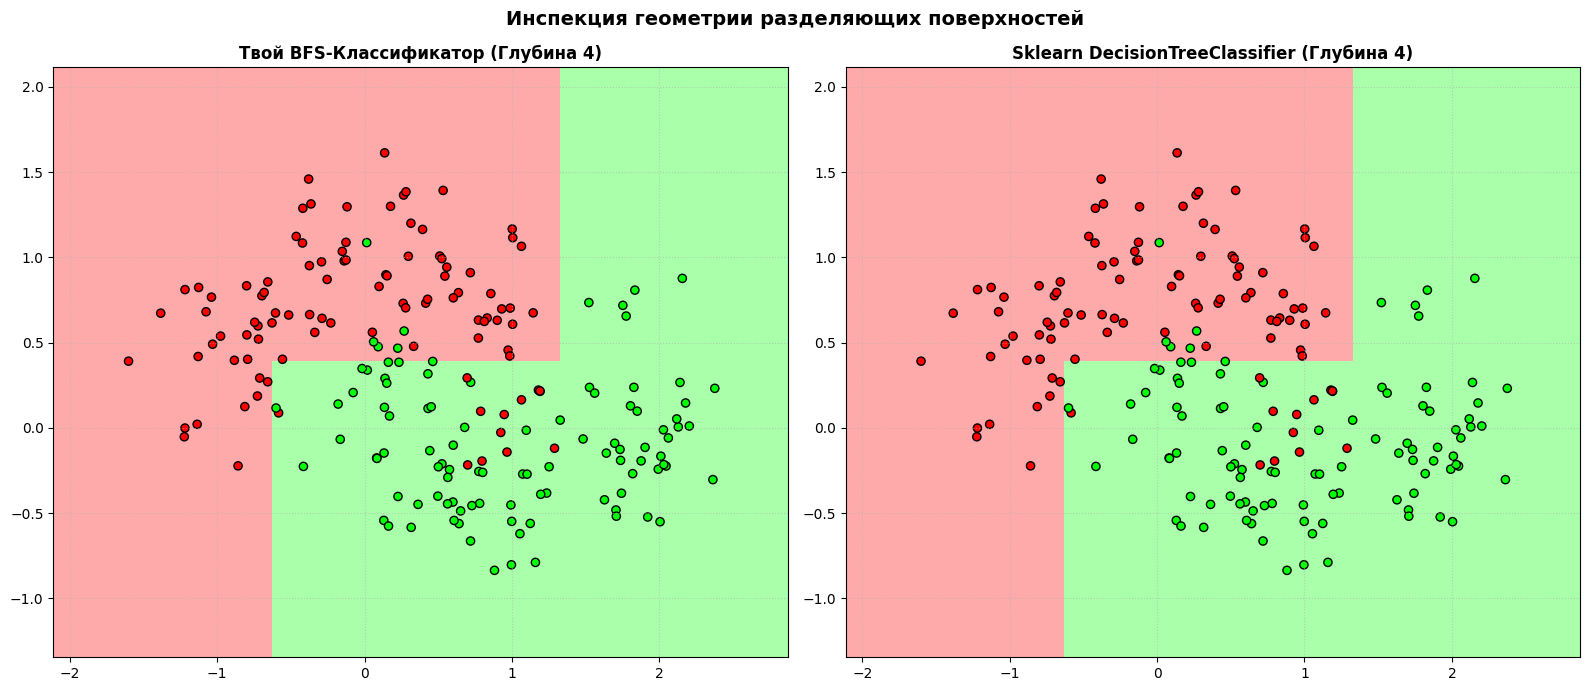

In [7]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_moons
from sklearn.metrics import accuracy_score
import numpy as np

# 1. Генерируем нелинейную выборку для классификации
X_moons, y_moons = make_moons(n_samples=200, noise=0.25, random_state=42)

# 2. Параметры дерева решений
DEPTH = 4
MIN_SPLIT = 2
TOLERANCE = 0.001
CRITERION = 'entropy'

# 3. Обучаем кастомное BFS-дерево
custom_tree = DecisionTreeClassification().fit(
    X_moons, y_moons,
    max_depth=DEPTH,
    min_samples_split=MIN_SPLIT,
    tol=TOLERANCE,
    impurity_func=CRITERION
)

# 4. Обучаем классическое дерево из Sklearn
sk_tree = DecisionTreeClassifier(
    max_depth=DEPTH,
    min_samples_split=MIN_SPLIT,
    min_impurity_decrease=TOLERANCE,
    criterion=CRITERION,
    random_state=42
).fit(X_moons, y_moons)

# 5. Сетка для отрисовки разделяющей поверхности (Decision Boundary)
h = 0.02
x_min, x_max = X_moons[:, 0].min() - 0.5, X_moons[:, 0].max() + 0.5
y_min, y_max = X_moons[:, 1].min() - 0.5, X_moons[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Делаем предсказания по всей сетке пространства признаков
Z_custom = custom_tree.predict(grid_points).reshape(xx.shape)
Z_sklearn = sk_tree.predict(grid_points).reshape(xx.shape)

# 6. Считаем метрики совпадения алгоритмов
acc_custom = accuracy_score(y_moons, custom_tree.predict(X_moons))
acc_sklearn = accuracy_score(y_moons, sk_tree.predict(X_moons))
boundary_match = np.mean(Z_custom == Z_sklearn) * 100

print("=" * 70)
print("СВОДКА ТЕСТИРОВАНИЯ: BFS DECISION TREE")
print("=" * 70)
print(f"Accuracy на тренировочном датасете (Miniml): {acc_custom:.4f}")
print(f"Accuracy на тренировочном датасете (Sklearn): {acc_sklearn:.4f}")
print(f"Идентичность разделяющих поверхностей: {boundary_match:.2f}%")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA'])
cmap_bold = ['#FF0000', '#00FF00']

# График твоего класса
axes[0].pcolormesh(xx, yy, Z_custom, cmap=cmap_light, shading='auto')
axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=[cmap_bold[i] for i in y_moons], edgecolor='k', s=35)
axes[0].set_title(f"Твой BFS-Классификатор (Глубина {DEPTH})", fontsize=12, fontweight='bold')
axes[0].grid(True, linestyle=':', alpha=0.6)

# График Sklearn
axes[1].pcolormesh(xx, yy, Z_sklearn, cmap=cmap_light, shading='auto')
axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=[cmap_bold[i] for i in y_moons], edgecolor='k', s=35)
axes[1].set_title(f"Sklearn DecisionTreeClassifier (Глубина {DEPTH})", fontsize=12, fontweight='bold')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.suptitle("Инспекция геометрии разделяющих поверхностей", fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()